# TAO ADCP Mixing Validation: Sensitivity to $Ri_\infty$

Compares three TPOSE24 configurations with different $Ri_\infty$ mixing thresholds against TAO ADCP observations at 0°N, 140°W.

**Runs:**
- `oct2012_3month_transp_cons` — $Ri_\infty = 0.7$
- `oct2012_TP6Vel_3month_Ri5` — $Ri_\infty = 0.5$
- `oct2012_TP6Vel_3month_Ri3` — $Ri_\infty = 0.3$

**Data:** `TAO_WO_2012_ADCP_v2_model.nc` from the MITprof framework  
**Location:** 0°N, 140°W  
**Period:** Oct–Dec 2012  
**Depths:** 10–315 m

### Figures
1. Hovmöller: observed U/V + all three model runs (2 rows × 4 cols)
2. Hovmöller: velocity error (obs − model) for all three runs (2 rows × 3 cols)
3. Time-mean depth profiles with ±1σ shading: obs vs all three models
4. RMS error, bias (±1σ), and correlation vs depth
5. Zonal velocity time series + zonal error time series
6. Meridional velocity time series + meridional error time series
7. Scatter plots: obs vs model for each run

In [1]:
RUNS = {
    r'$Ri_\infty = 0.7$': '/data/SO3/edavenport/tpose24/oct2012_3month_transp_cons',
    r'$Ri_\infty = 0.5$': '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri5',
    r'$Ri_\infty = 0.3$': '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri3',
}
RUN_COLORS = ['C0', 'C1', 'C2']
OUT_DIR    = 'TAO_comparison/mixing_comparison'

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean.cm as cmo
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})

os.makedirs(OUT_DIR, exist_ok=True)
RUN_LABELS = list(RUNS.keys())
RUN_DIRS   = list(RUNS.values())

## 1. Load and pre-process

In [3]:
def parse_datetime(yyyymmdd, hhmmss):
    d = int(yyyymmdd)
    t = int(hhmmss)
    yr, mo, dy = d // 10000, (d % 10000) // 100, d % 100
    hh, mm, ss = t // 10000, (t % 10000) // 100, t % 100
    return pd.Timestamp(yr, mo, dy, hh, mm, ss)

TARGET_LON = -140.

run_data = {}
for label, run_dir in RUNS.items():
    data_path = f'{run_dir}/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'
    ds = xr.open_dataset(data_path)

    lons      = ds['prof_lon'].values
    depths    = ds['prof_depth'].values
    dates_raw = ds['prof_YYYYMMDD'].values
    times_raw = ds['prof_HHMMSS'].values
    U         = ds['prof_U'].values.astype(float)
    V         = ds['prof_V'].values.astype(float)
    Uestim    = ds['prof_Uestim'].values.astype(float)
    Vestim    = ds['prof_Vestim'].values.astype(float)

    timestamps = np.array([parse_datetime(d, t) for d, t in zip(dates_raw, times_raw)])
    lon_mask   = lons == TARGET_LON
    estim_mask = ~np.isnan(Uestim[lon_mask]).any(axis=1)

    run_data[label] = {
        'depths':     depths,
        'timestamps': timestamps[lon_mask][estim_mask],
        'U':          U[lon_mask][estim_mask],
        'V':          V[lon_mask][estim_mask],
        'Uestim':     Uestim[lon_mask][estim_mask],
        'Vestim':     Vestim[lon_mask][estim_mask],
    }
    print(f'{label}: {len(run_data[label]["timestamps"])} profiles')

depths = run_data[RUN_LABELS[0]]['depths']
n_z    = len(depths)
Z      = -depths
print(f'Depths: {n_z} levels, {depths[0]:.0f}\u2013{depths[-1]:.0f} m')

$Ri_\infty = 0.7$: 2180 profiles
$Ri_\infty = 0.5$: 2183 profiles
$Ri_\infty = 0.3$: 2183 profiles
Depths: 62 levels, 10–315 m


In [5]:
def daily_average(arr2d, day_idx, unique_days):
    out = np.full((len(unique_days), arr2d.shape[1]), np.nan)
    for i, day in enumerate(unique_days):
        sel = day_idx == day
        if sel.sum() == 0:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            out[i] = np.nanmean(arr2d[sel], axis=0)
    return out

for label in RUN_LABELS:
    d = run_data[label]
    day_index   = pd.DatetimeIndex(d['timestamps']).normalize()
    unique_days = pd.date_range(day_index.min(), day_index.max(), freq='D')

    U_day  = daily_average(d['U'],      day_index, unique_days)
    V_day  = daily_average(d['V'],      day_index, unique_days)
    Ue_day = daily_average(d['Uestim'], day_index, unique_days) + U_day - U_day
    Ve_day = daily_average(d['Vestim'], day_index, unique_days) + V_day - V_day # add and subtract just cheap way to preserve NaN structure

    dU_dz_day  = np.gradient(U_day,  depths, axis=1)
    dV_dz_day  = np.gradient(V_day,  depths, axis=1)
    dUe_dz_day = np.gradient(Ue_day, depths, axis=1)
    dVe_dz_day = np.gradient(Ve_day, depths, axis=1)

    d.update({
        'U_day':       U_day,
        'V_day':       V_day,
        'Ue_day':      Ue_day,
        'Ve_day':      Ve_day,
        'dU_day':      U_day - Ue_day,
        'dV_day':      V_day - Ve_day,
        'dU_dz_day':   dU_dz_day,
        'dV_dz_day':   dV_dz_day,
        'dUe_dz_day':  dUe_dz_day,
        'dVe_dz_day':  dVe_dz_day,
        'd_shear_U':   dU_dz_day  - dUe_dz_day,
        'd_shear_V':   dV_dz_day  - dVe_dz_day,
        'unique_days': unique_days,
        'T':           unique_days.to_pydatetime(),
    })

T      = run_data[RUN_LABELS[0]]['T']
n_days = len(T)
print(f'Daily grid: {n_days} days × {n_z} depths')

Daily grid: 91 days × 62 depths


## 2. Hovmöller: velocity and error by component

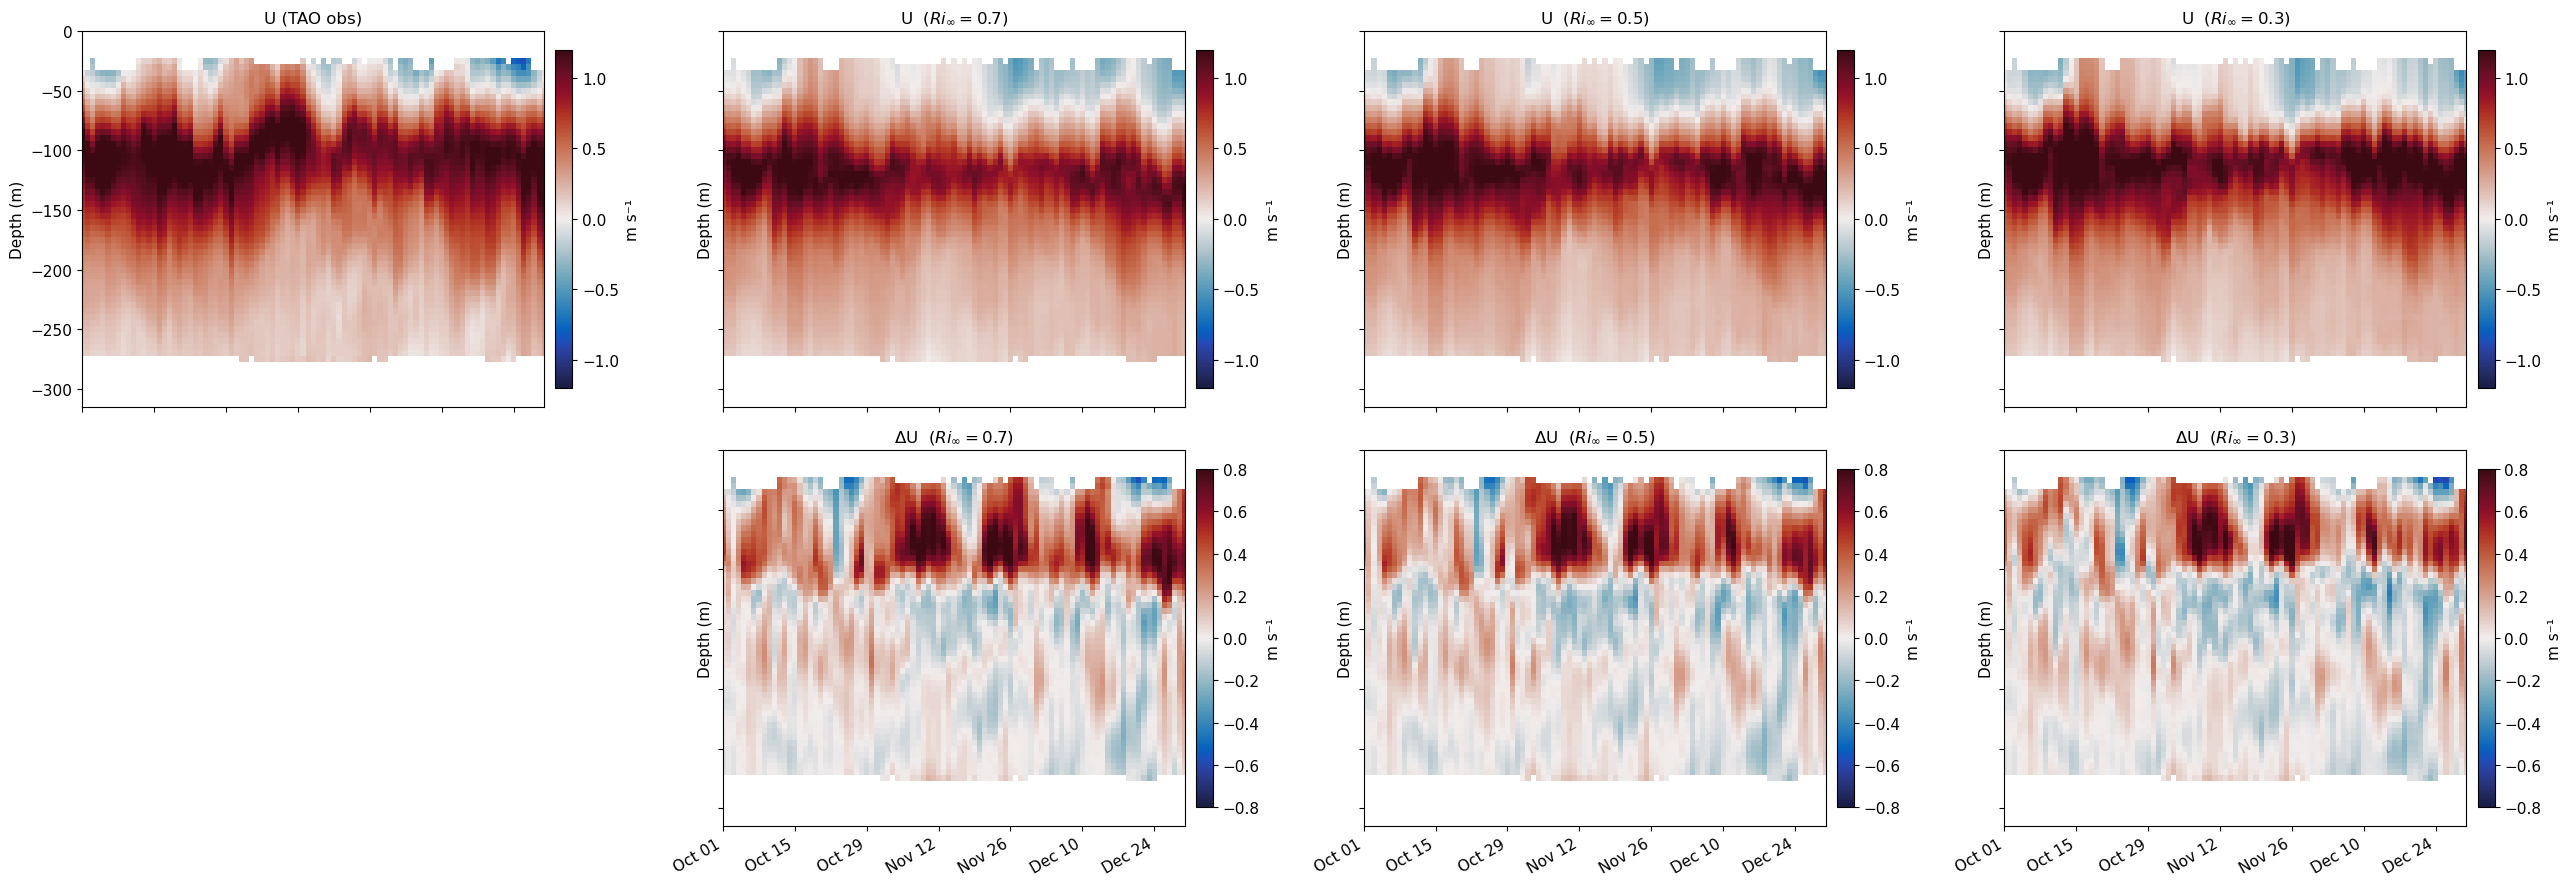

Saved fig1_zonal_hovm.png


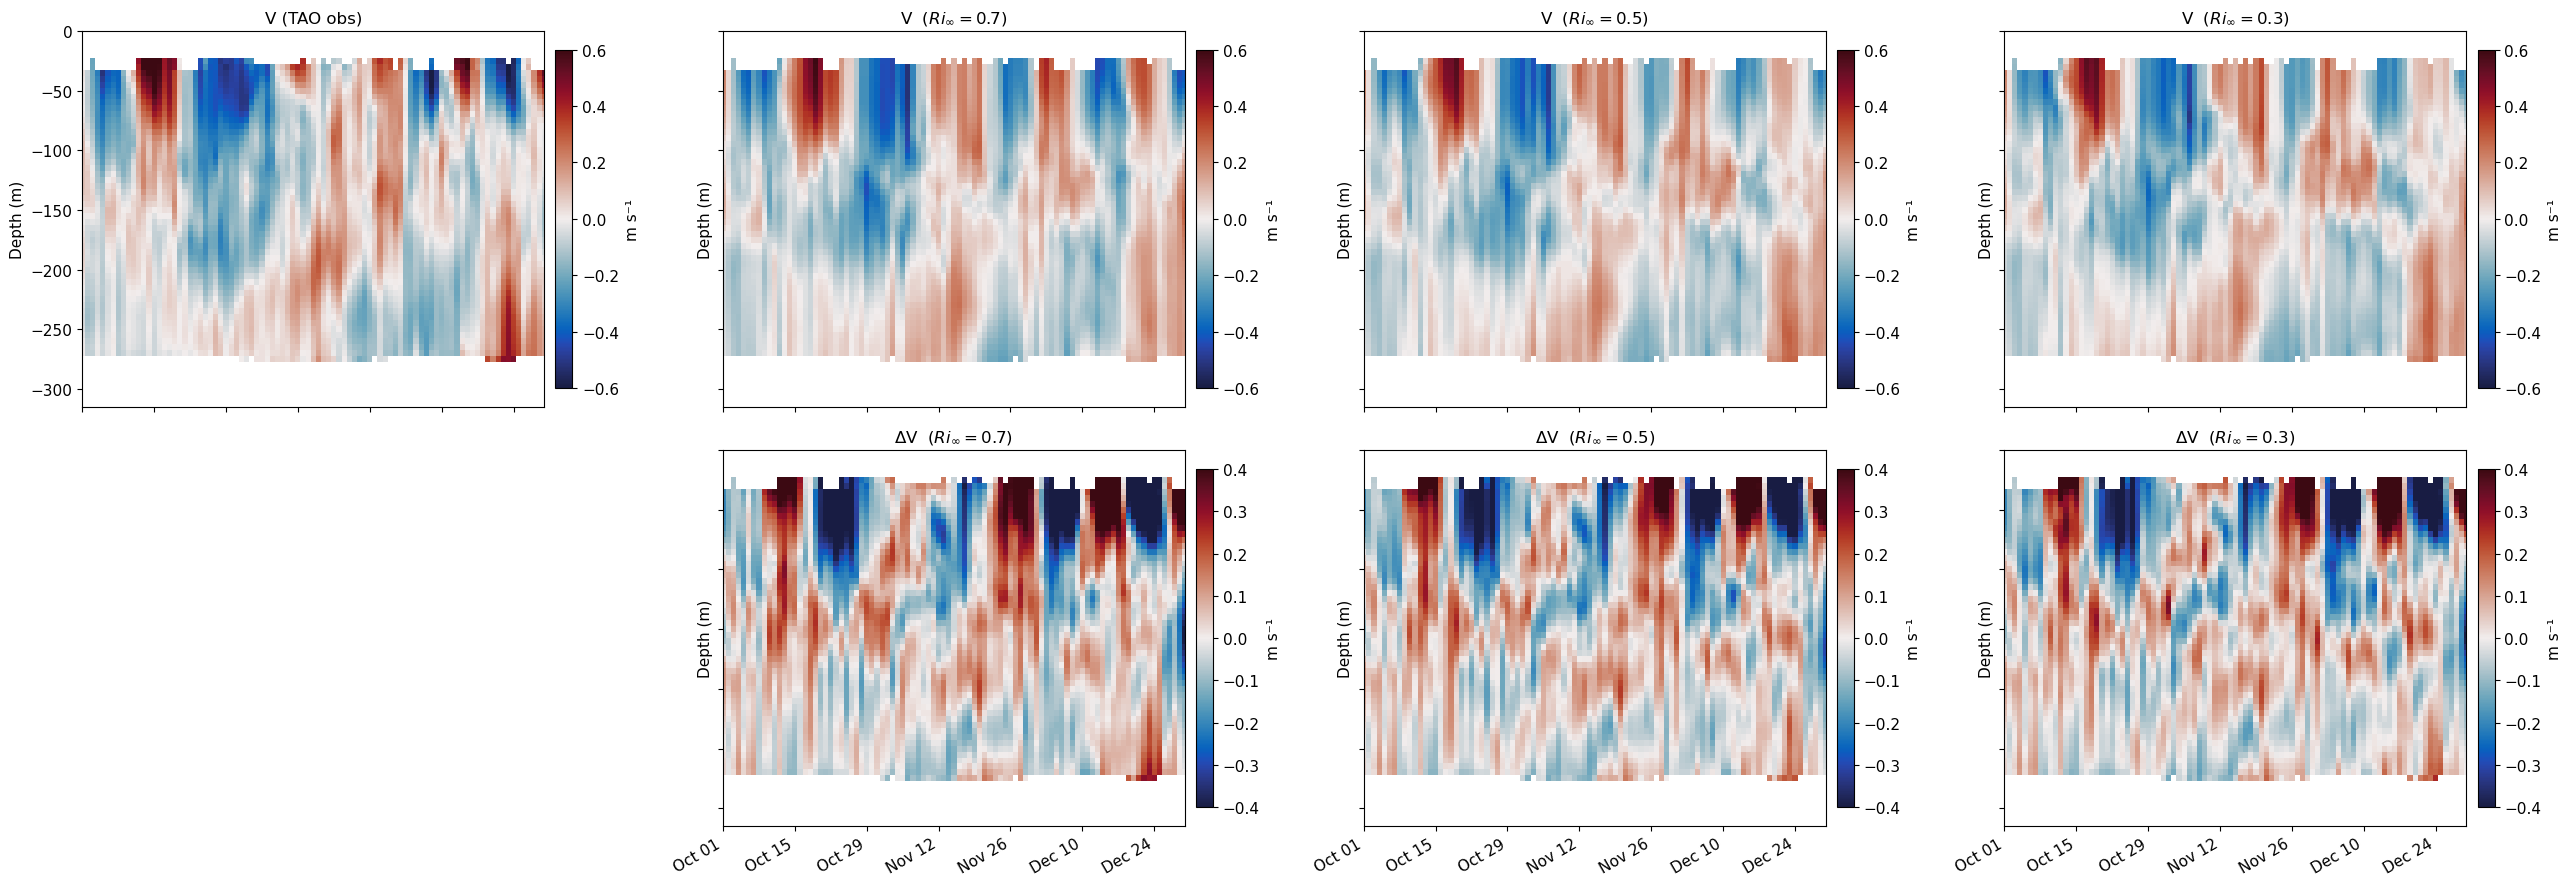

Saved fig2_meridional_hovm.png


In [6]:
def hovm(ax, data, T, Z, cmap, vmax, clabel, title):
    im = ax.pcolormesh(T, Z, data.T, cmap=cmap,
                       vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_ylabel('Depth (m)')
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    cb = plt.colorbar(im, ax=ax, pad=0.02, shrink=0.9)
    cb.set_label(clabel)
    return im

for comp, key_obs, key_mod, key_err, vmax_v, vmax_e, fname in [
    ('U', 'U_day', 'Ue_day', 'dU_day', 1.2, 0.8, 'fig1_zonal_hovm.png'),
    ('V', 'V_day', 'Ve_day', 'dV_day', 0.6, 0.4, 'fig2_meridional_hovm.png'),
]:
    d0  = run_data[RUN_LABELS[0]]
    fig, axes = plt.subplots(2, 4, figsize=(26, 9), sharex=True, sharey=True)

    # Row 0: obs + 3 models
    hovm(axes[0, 0], d0[key_obs], T, Z, cmo.balance, vmax_v, 'm s⁻¹', f'{comp} (TAO obs)')
    for col, label in enumerate(RUN_LABELS, start=1):
        d = run_data[label]
        hovm(axes[0, col], d[key_mod], T, Z, cmo.balance, vmax_v, 'm s⁻¹', f'{comp}  ({label})')

    # Row 1: 3 error panels aligned under the 3 model columns
    axes[1, 0].set_visible(False)
    for col, label in enumerate(RUN_LABELS, start=1):
        d = run_data[label]
        hovm(axes[1, col], d[key_err], T, Z, cmo.balance, vmax_e, 'm s⁻¹', f'Δ{comp}  ({label})')

    for ax in list(axes[0, :]) + list(axes[1, 1:]):
        ax.set_ylim([-315, 0])
        ax.set_xlim([T[0], T[-1]])

    fig.tight_layout()
    plt.savefig(f'{OUT_DIR}/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

## 4. Time-mean depth profiles

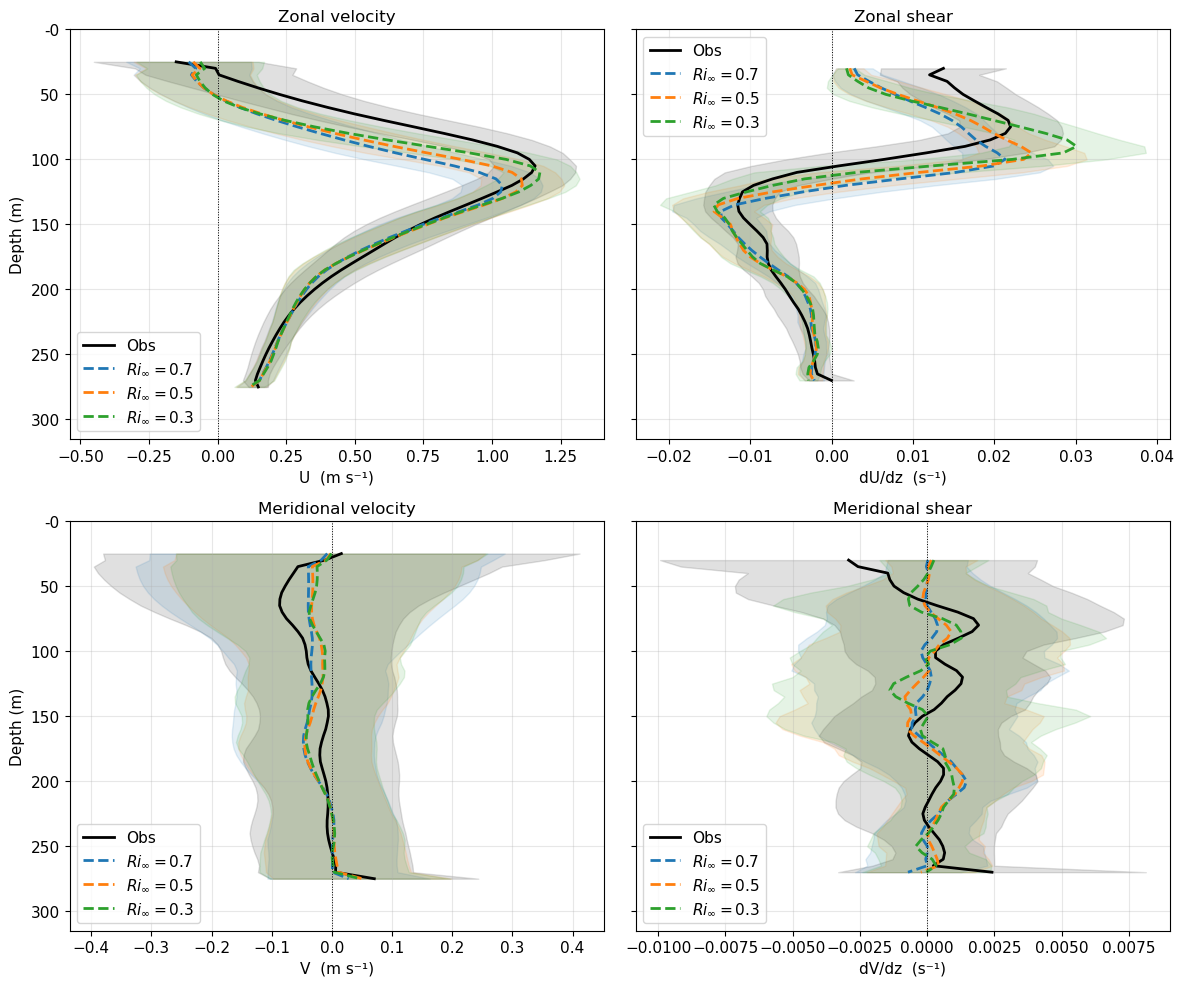

Saved fig3_mean_profiles.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

d0 = run_data[RUN_LABELS[0]]

for row, (key_obs, key_mod, key_shear_obs, key_shear_mod,
          xlabel_v, xlabel_s, title_v, title_s) in enumerate([
    ('U_day',  'Ue_day',  'dU_dz_day',  'dUe_dz_day',
     'U  (m s⁻¹)',  'dU/dz  (s⁻¹)',  'Zonal velocity',      'Zonal shear'),
    ('V_day',  'Ve_day',  'dV_dz_day',  'dVe_dz_day',
     'V  (m s⁻¹)',  'dV/dz  (s⁻¹)',  'Meridional velocity', 'Meridional shear'),
]):
    obs_mean       = np.nanmean(d0[key_obs],       axis=0)
    obs_std        = np.nanstd(d0[key_obs],        axis=0)
    shear_obs_mean = np.nanmean(d0[key_shear_obs], axis=0)
    shear_obs_std  = np.nanstd(d0[key_shear_obs],  axis=0)

    ax   = axes[row, 0]
    ax_s = axes[row, 1]

    ax.plot(obs_mean, Z, color='k', lw=2, label='Obs')
    ax.fill_betweenx(Z, obs_mean - obs_std, obs_mean + obs_std, color='k', alpha=0.12)
    ax_s.plot(shear_obs_mean, Z, color='k', lw=2, label='Obs')
    ax_s.fill_betweenx(Z, shear_obs_mean - shear_obs_std,
                       shear_obs_mean + shear_obs_std, color='k', alpha=0.12)

    for label, color in zip(RUN_LABELS, RUN_COLORS):
        d              = run_data[label]
        mod_mean       = np.nanmean(d[key_mod],       axis=0)
        mod_std        = np.nanstd(d[key_mod],        axis=0)
        shear_mod_mean = np.nanmean(d[key_shear_mod], axis=0)
        shear_mod_std  = np.nanstd(d[key_shear_mod],  axis=0)
        ax.plot(mod_mean, Z, color=color, lw=2, ls='--', label=label)
        ax.fill_betweenx(Z, mod_mean - mod_std, mod_mean + mod_std, color=color, alpha=0.12)
        ax_s.plot(shear_mod_mean, Z, color=color, lw=2, ls='--', label=label)
        ax_s.fill_betweenx(Z, shear_mod_mean - shear_mod_std,
                           shear_mod_mean + shear_mod_std, color=color, alpha=0.12)

    for ax_, xlabel, title in [(ax, xlabel_v, title_v), (ax_s, xlabel_s, title_s)]:
        ax_.axvline(0, color='k', lw=0.7, ls=':')
        ax_.set_xlabel(xlabel)
        ax_.set_title(title)
        ax_.legend()
        ax_.grid(alpha=0.3)
        ax_.set_ylim([-315, 0])
        ax_.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{-y:.0f}'))
    ax.set_ylabel('Depth (m)')

fig.tight_layout()
plt.savefig(f'{OUT_DIR}/fig3_mean_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3_mean_profiles.png')

## 5. RMS error and bias profiles

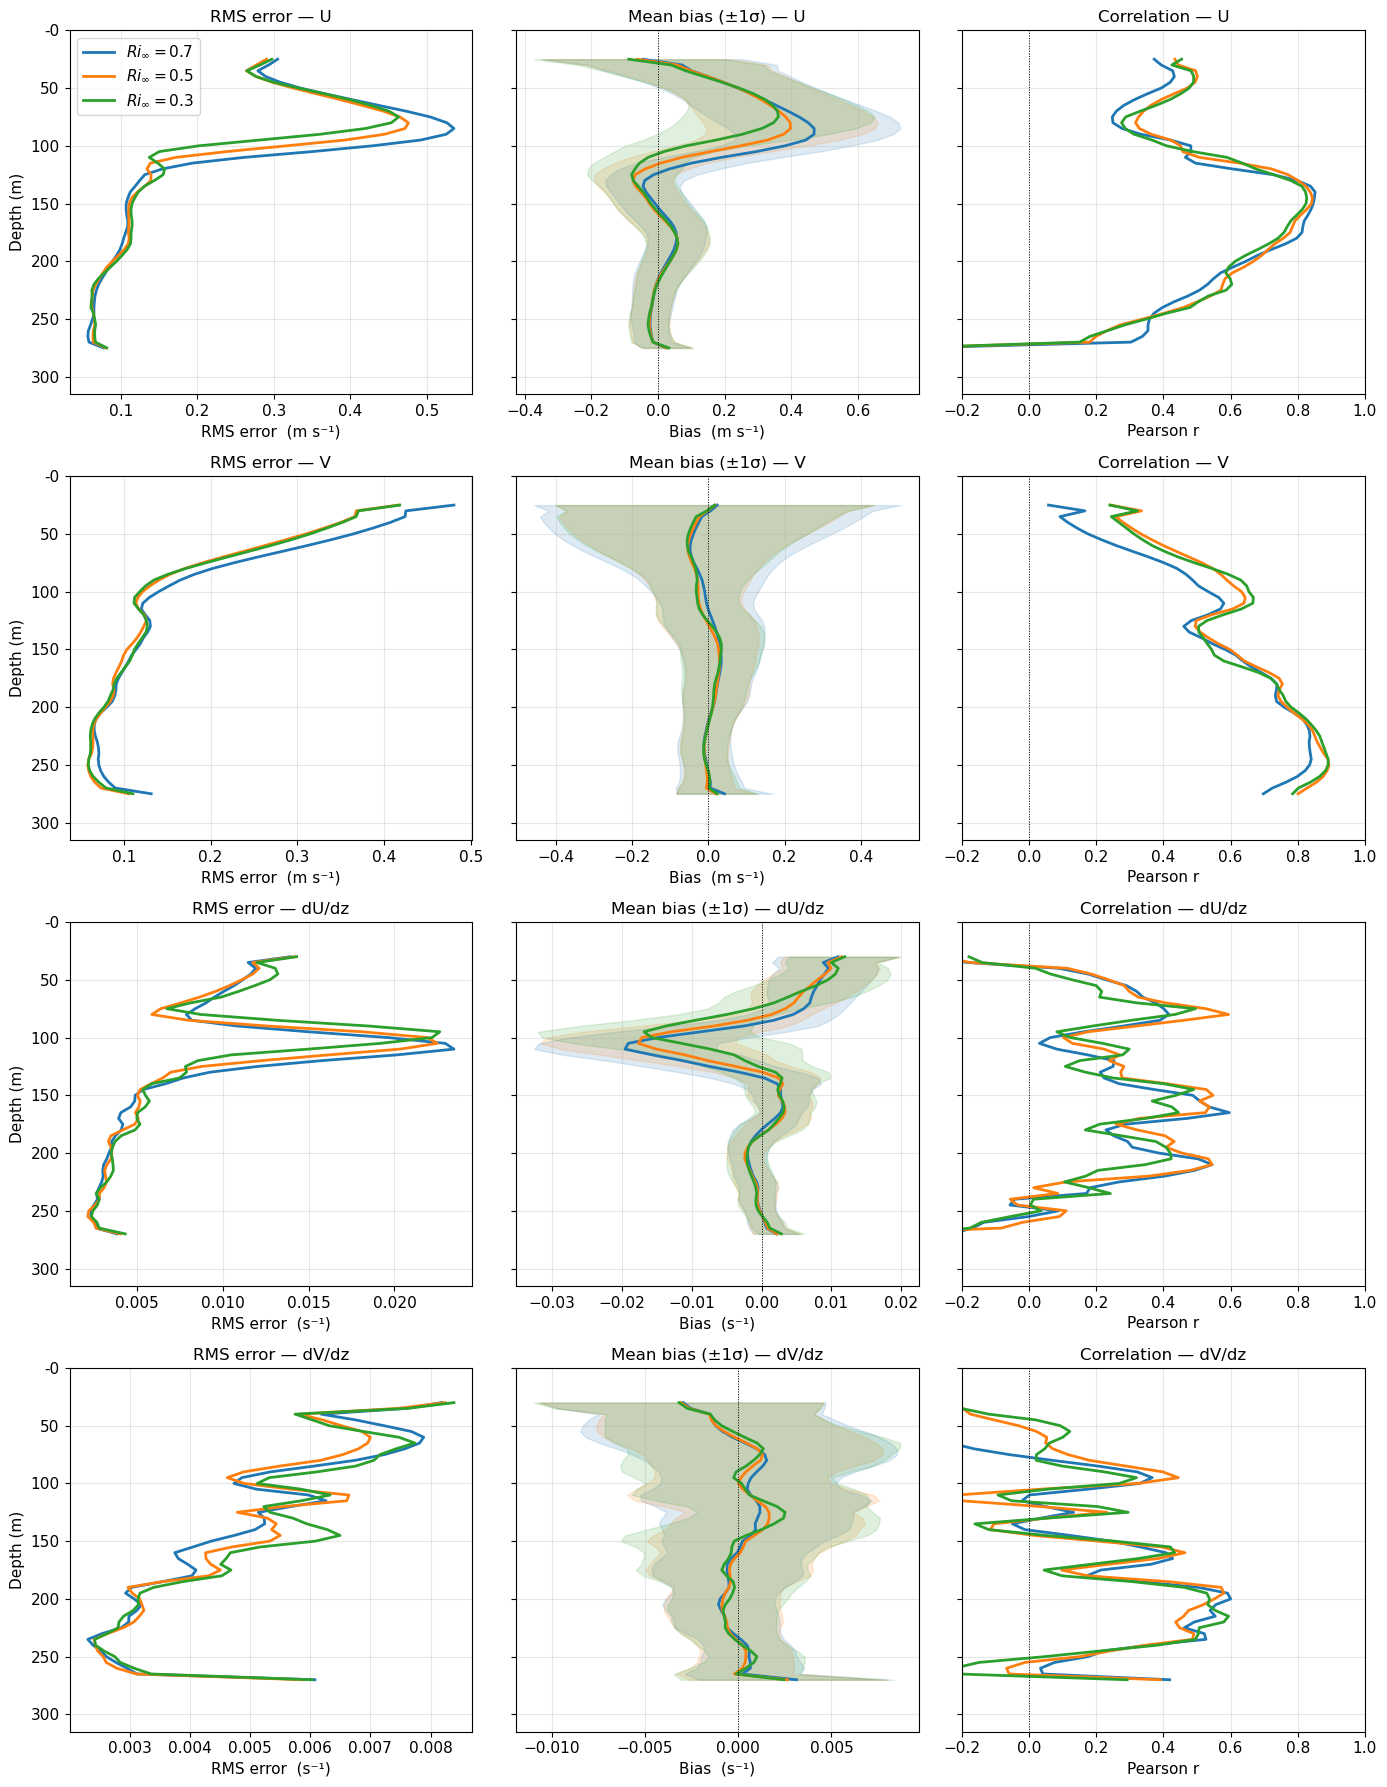

Saved fig4_error_profiles.png


In [8]:
fig, axes = plt.subplots(4, 3, figsize=(14, 18), sharey=True)

for row, (comp, key_obs, key_mod, key_err, unit) in enumerate([
    ('U',     'U_day',     'Ue_day',     'dU_day',    'm s⁻¹'),
    ('V',     'V_day',     'Ve_day',     'dV_day',    'm s⁻¹'),
    ('dU/dz', 'dU_dz_day', 'dUe_dz_day', 'd_shear_U', 's⁻¹'),
    ('dV/dz', 'dV_dz_day', 'dVe_dz_day', 'd_shear_V', 's⁻¹'),
]):
    for label, color in zip(RUN_LABELS, RUN_COLORS):
        d    = run_data[label]
        err  = d[key_err]
        rms  = np.sqrt(np.nanmean(err**2, axis=0))
        bias = np.nanmean(err, axis=0)
        bstd = np.nanstd(err,  axis=0)
        corr = np.full(n_z, np.nan)
        obs_ = d[key_obs]
        mod_ = d[key_mod]
        for k in range(n_z):
            mask = ~np.isnan(obs_[:, k]) & ~np.isnan(mod_[:, k])
            if mask.sum() > 5:
                corr[k] = np.corrcoef(obs_[mask, k], mod_[mask, k])[0, 1]

        axes[row, 0].plot(rms,  Z, color=color, lw=2, label=label)
        axes[row, 1].plot(bias, Z, color=color, lw=2, label=label)
        axes[row, 1].fill_betweenx(Z, bias - bstd, bias + bstd, color=color, alpha=0.15)
        axes[row, 2].plot(corr, Z, color=color, lw=2, label=label)

    axes[row, 0].set_xlabel(f'RMS error  ({unit})')
    axes[row, 1].set_xlabel(f'Bias  ({unit})')
    axes[row, 2].set_xlabel('Pearson r')
    axes[row, 0].set_title(f'RMS error — {comp}')
    axes[row, 1].set_title(f'Mean bias (±1σ) — {comp}')
    axes[row, 2].set_title(f'Correlation — {comp}')
    axes[row, 1].axvline(0, color='k', lw=0.7, ls=':')
    axes[row, 2].axvline(0, color='k', lw=0.7, ls=':')
    axes[row, 2].set_xlim([-0.2, 1.0])
    for col in range(3):
        axes[row, col].set_ylim([-315, 0])
        axes[row, col].grid(alpha=0.3)
        axes[row, col].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{-y:.0f}'))
        if col == 0:
            axes[row, col].set_ylabel('Depth (m)')

axes[0, 0].legend()
fig.tight_layout()
plt.savefig(f'{OUT_DIR}/fig4_error_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig4_error_profiles.png')

## 6. Velocity time series at selected depths

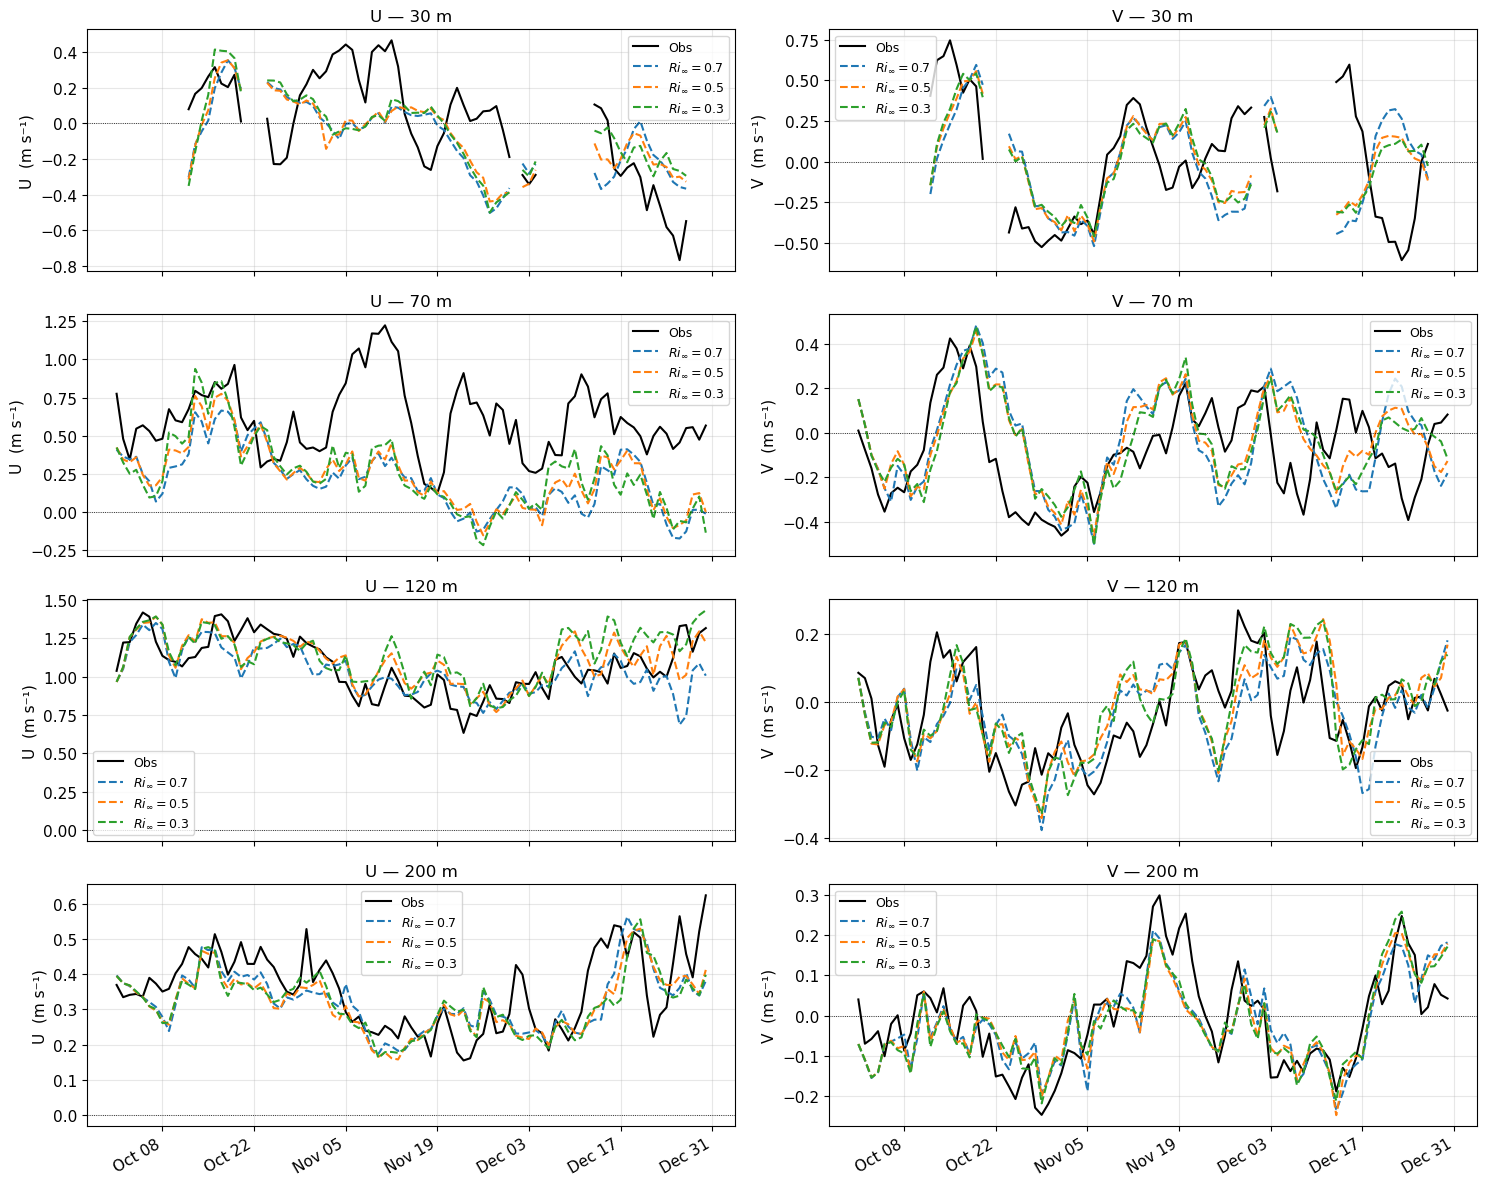

Saved fig5_timeseries.png


In [9]:
target_depths = [30, 70, 120, 200]
depth_labels  = ['30 m', '70 m', '120 m', '200 m']
depth_idx     = [np.argmin(np.abs(depths - dd)) for dd in target_depths]

d0 = run_data[RUN_LABELS[0]]
fig, axes = plt.subplots(len(target_depths), 2, figsize=(15, 12), sharex=True)

for row, (di, dlabel) in enumerate(zip(depth_idx, depth_labels)):
    for col, (comp, key_obs, key_mod) in enumerate([
        ('U', 'U_day', 'Ue_day'),
        ('V', 'V_day', 'Ve_day'),
    ]):
        ax = axes[row, col]
        ax.plot(T, d0[key_obs][:, di], color='k', lw=1.5, label='Obs')
        for label, color in zip(RUN_LABELS, RUN_COLORS):
            d = run_data[label]
            ax.plot(T, d[key_mod][:, di], color=color, lw=1.5, ls='--', label=label)
        ax.axhline(0, color='k', lw=0.6, ls=':')
        ax.set_ylabel(f'{comp}  (m s⁻¹)')
        ax.set_title(f'{comp} — {dlabel}')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))

for ax in axes[-1]:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
plt.savefig(f'{OUT_DIR}/fig5_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig5_timeseries.png')

## 7. Scatter plots: obs vs model

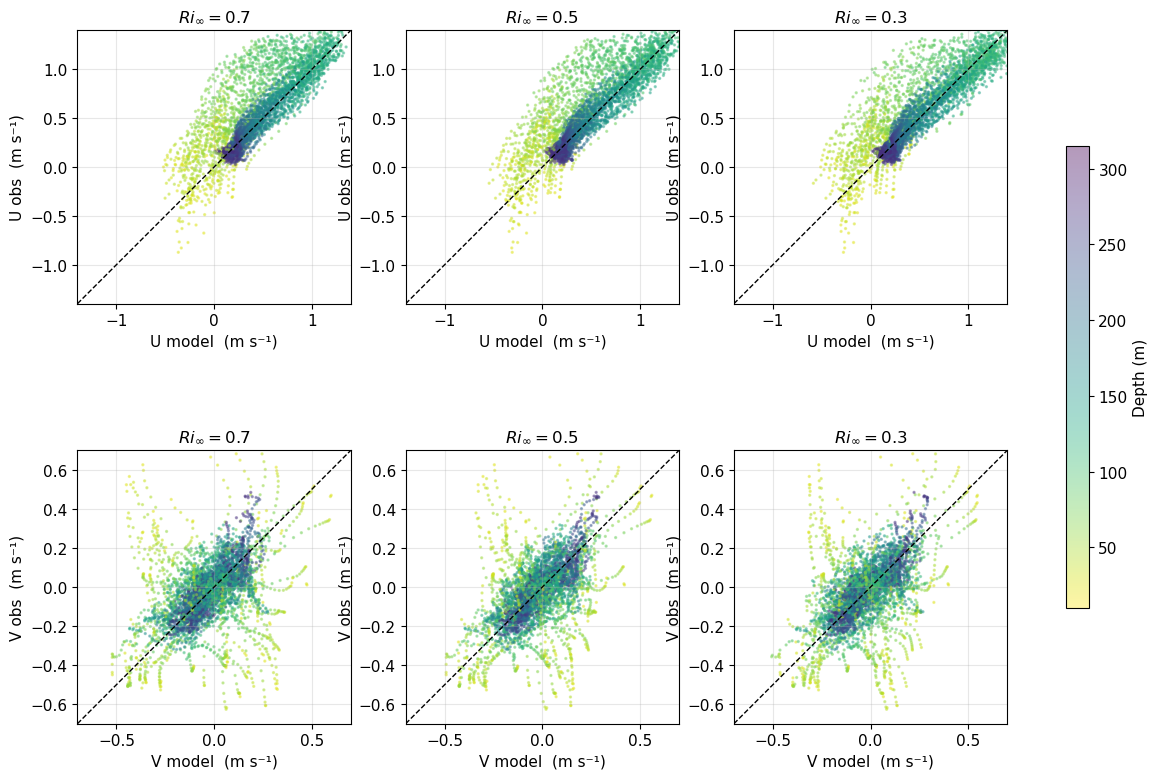

Saved fig6_scatter.png


In [11]:
depth_tile = np.tile(depths, (n_days, 1))

def scatter_vs_model(ax, obs, model, depth, comp, vrange):
    mask = ~np.isnan(obs) & ~np.isnan(model)
    o, m, dz = obs[mask], model[mask], depth[mask]
    sc = ax.scatter(m, o, c=dz, cmap='viridis_r', s=2, alpha=0.4,
                    vmin=depths.min(), vmax=depths.max(), rasterized=True)
    lims = [vrange[0], vrange[1]]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(f'{comp} model  (m s⁻¹)')
    ax.set_ylabel(f'{comp} obs  (m s⁻¹)')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    return sc

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, label in enumerate(RUN_LABELS):
    d = run_data[label]
    sc_u = scatter_vs_model(axes[0, col], d['U_day'].ravel(), d['Ue_day'].ravel(),
                             depth_tile.ravel(), 'U', [-1.4, 1.4])
    sc_v = scatter_vs_model(axes[1, col], d['V_day'].ravel(), d['Ve_day'].ravel(),
                             depth_tile.ravel(), 'V', [-0.7, 0.7])
    axes[0, col].set_title(label)
    axes[1, col].set_title(label)

cb = fig.colorbar(sc_u, ax=axes.ravel().tolist(), shrink=0.6, pad=0.05)
cb.set_label('Depth (m)')

# fig.tight_layout()
plt.savefig(f'{OUT_DIR}/fig6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig6_scatter.png')